In [1]:
import os
import sys
from os import listdir
from os.path import join as opj
import xarray as xr
import dask.array as da
from dask import dataframe as ddf
import dask as dk
from dask.distributed import Client, LocalCluster
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from ezyrb import POD, RBF
from pydmd import HODMD, ParametricDMD
from scipy.signal import detrend
from scipy.integrate import cumulative_trapezoid

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica"
})

In [2]:

# # Set up a local cluster with 4 cores
# cluster = LocalCluster(n_workers=4, threads_per_worker=1, processes=True)
# client = Client(cluster)

# # Check the client and cluster status
# print(client)


In [3]:
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

Path2ParquetData = os.path.join(os.path.abspath(""),
                                r'..', r'data', r'parquet_data')

df = ddf.read_parquet(os.path.join(Path2ParquetData,
                                   "Datalogger.parquet"),
                      engine='pyarrow',)
df = df.set_index("Date_Heure", sorted=True)

In [4]:
# sampling rate in units of seconds (original sample rate is at 0.01 s)
fss = ('100','ms')
D=np.timedelta64(*fss)
# 15 minutes per acquisition
A=np.timedelta64('15', 'm').astype('timedelta64[s]')
# one second unit
U=np.timedelta64('1', 's').astype(f'timedelta64[{fss[1]}]')
rec = (A/(D/U)).astype(np.int64)
df = df.resample(''.join(fss)).first().dropna()

In [5]:


df = df.map_partitions(lambda dlf: dlf.assign(a_r=detrend(dlf.Capteur_1),
                                              a_t=detrend(dlf.Capteur_2)),
                       meta={"Capteur_1": 'f8',
                             "Capteur_2": 'f8',
                             "Temperature": 'f8',
                             "a_r": 'f8',
                             "a_t": 'f8'}
                         ).drop("Capteur_1", axis=1).drop("Capteur_2", axis=1)
df = df.map_partitions(lambda dlf: dlf.assign(v_r=cumulative_trapezoid(y=dlf.a_r,
                                                                       dx=(D/U).astype(np.float64),
                                                                       initial=0),
                                              v_t=cumulative_trapezoid(y=dlf.a_t,
                                                                       dx=(D/U).astype(np.float64),
                                                                       initial=0)),
                       meta={"Temperature": 'f8',
                             "a_r": 'f8',
                             "a_t": 'f8',
                             "v_r": 'f8',
                             "v_t": 'f8',}
                       )

In [ ]:
# chunk_sizes = list(df.map_partitions(len).values)
BeginDate = "2016-11-26"
EndDate = "2016-11-26"
Variables = {"a_r":0, "a_t":1, "Temperature":2, "v_r":3, "v_t":4}


dka = df.loc[BeginDate:EndDate,list(Variables.keys())].to_dask_array(lengths=True)




AttributeError: 'BlockView' object has no attribute 'compute'

In [17]:
dv_r = np.stack(
                [b.T.compute() for b in dka[:, Variables["v_r"]].blocks if b.size == rec]
                ).reshape(-1, 1, rec)
dv_t = np.stack(
                [b.T.compute() for b in dka[:, Variables["v_t"]].blocks if b.size == rec]
                ).reshape(-1, 1, rec)
T = np.stack(
             [b.T.compute() for b in dka[:, Variables["Temperature"]].blocks if b.size == rec]
             )

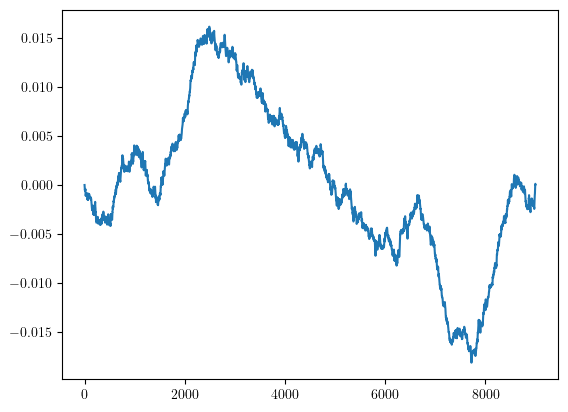

In [ ]:
plt.plot(dv_r[0,0,:])